# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [48]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [49]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



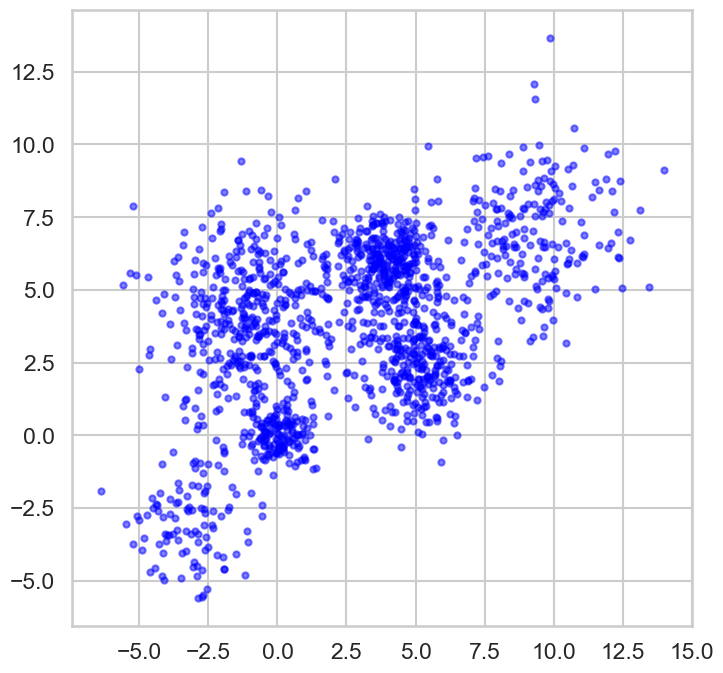

In [47]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

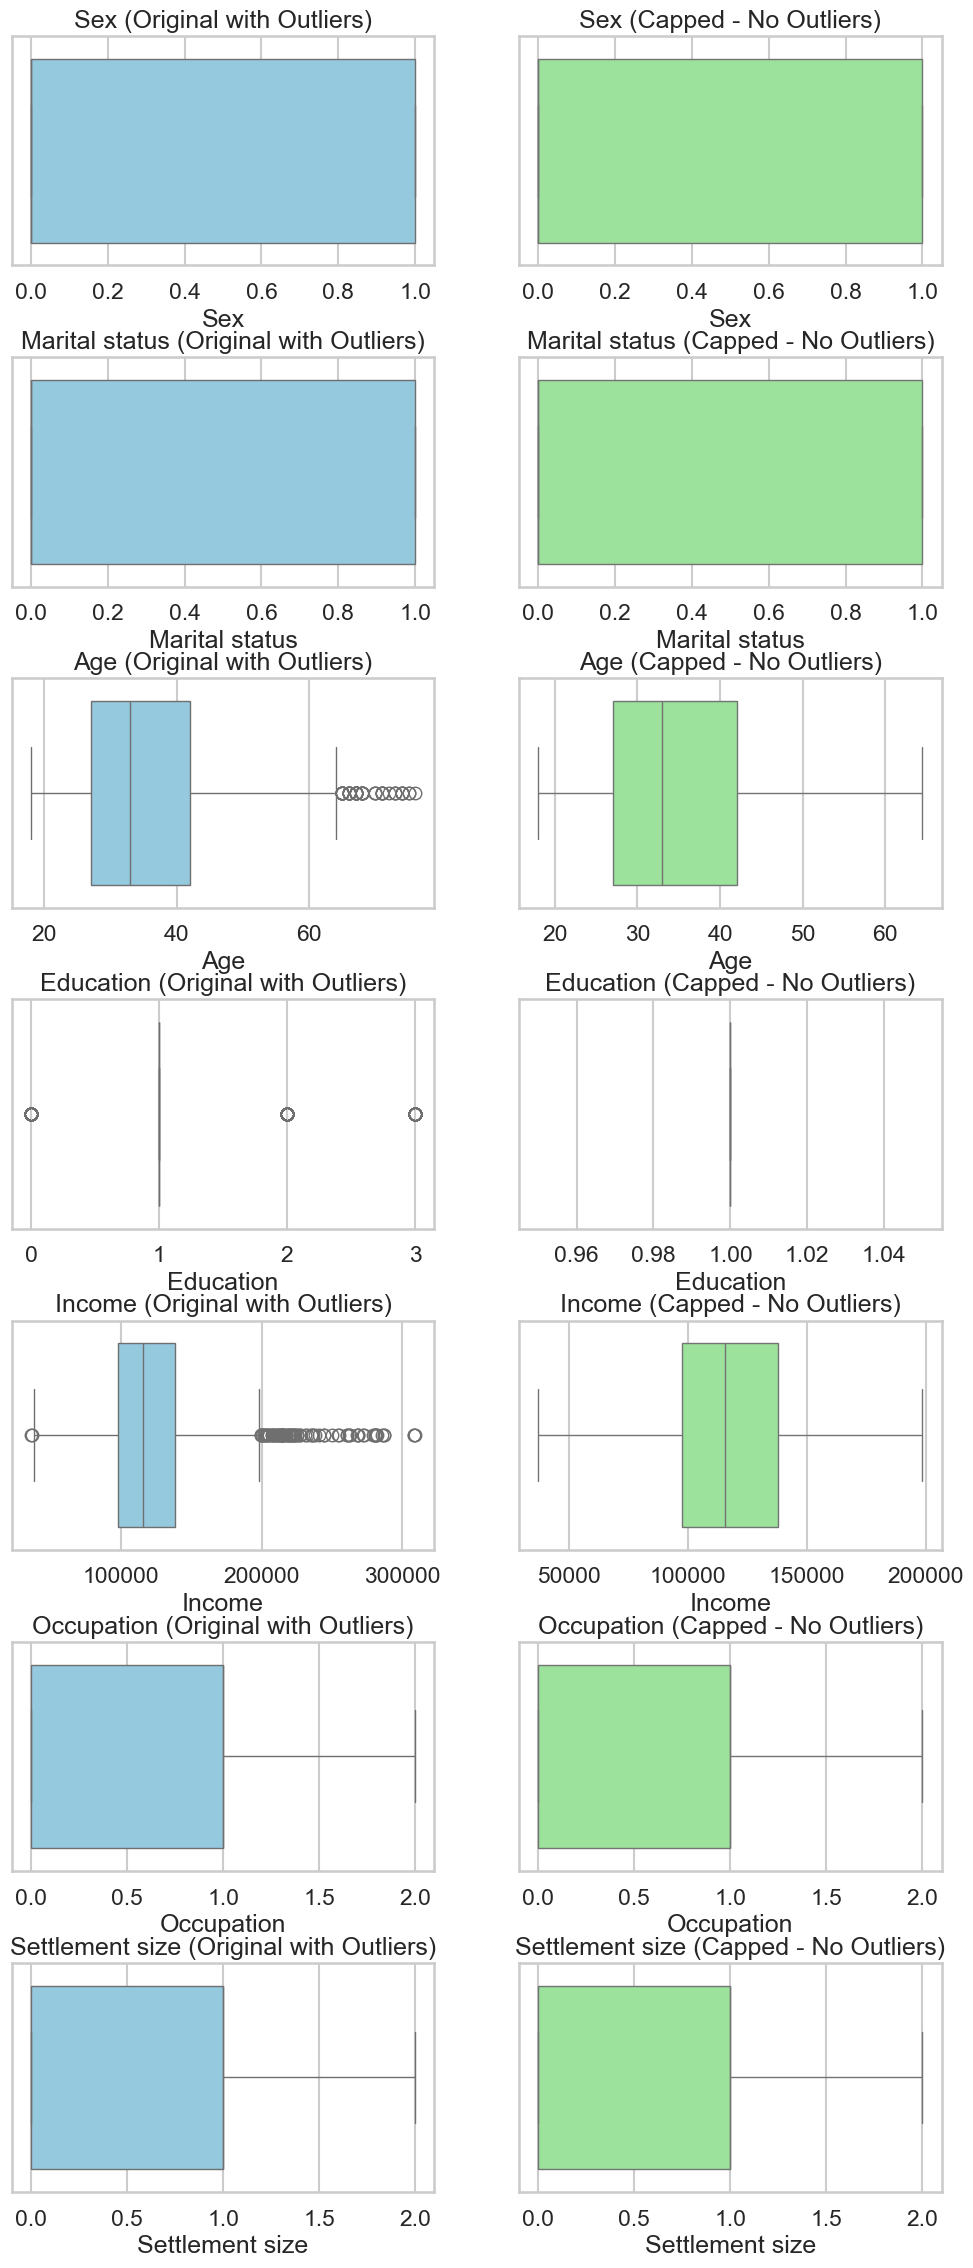

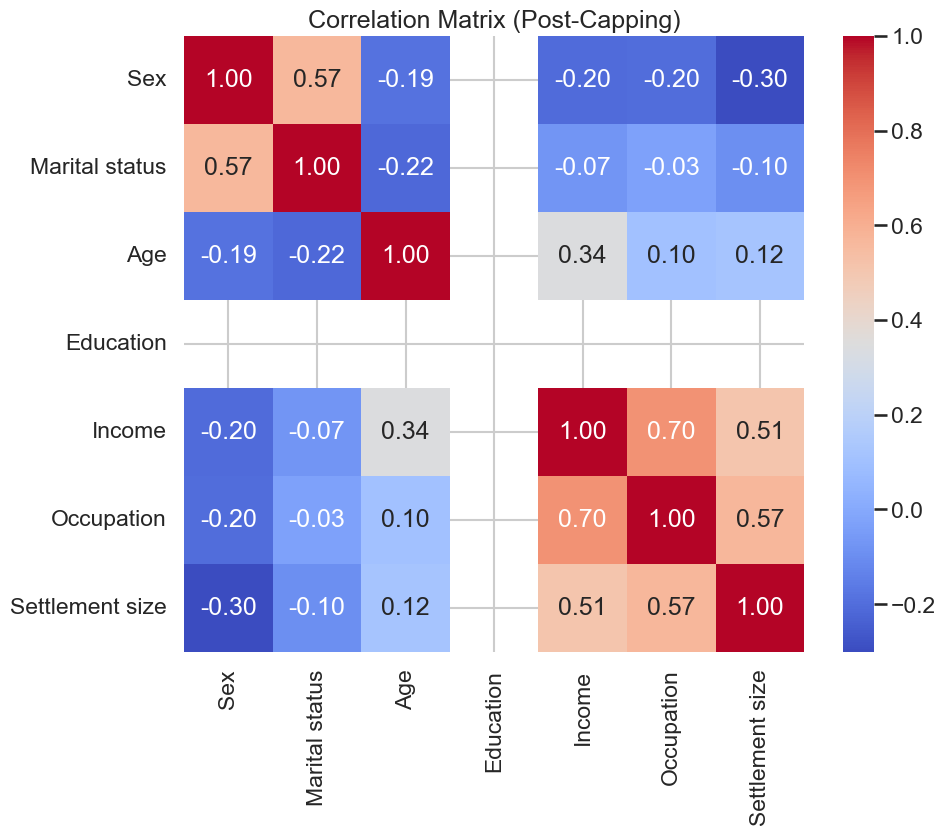

ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64


In [ ]:
                                                                            ## Customer Data Analysis
df = pd.read_csv('Customer Data.csv')

                                                # Identify numeric vs categorical features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Removed ID columns if they exist as they shouldn't be capped/scaled
if 'ID' in numeric_features: numeric_features.remove('ID')
df[col] = df[col].fillna(df[col].median())
# We'll create a second dataframe for the capped version
df_capped = df.copy()

# Setup plots for comparison
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(12, 4 * len(numeric_features)))
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(numeric_features):
    # boxplot before capping
    sns.boxplot(x=df[col], ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} (Original with Outliers)')
    
    # capping outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_capped[col] = np.clip(df[col], lower_bound, upper_bound)
    
    # boxplot after capping
    sns.boxplot(x=df_capped[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} (Capped - No Outliers)')



                             
plt.figure(figsize=(10, 8))
correlation_matrix = df_capped[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Post-Capping)')
plt.show()
print(df_capped.isnull().sum())



In [43]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_capped) 
df_final = pd.DataFrame(df_scaled_array, columns= df_capped.columns.tolist())
print(df_final.head())

         ID       Sex  Marital status       Age  Education    Income  \
0 -1.731185 -0.917399       -0.993024  2.515372        0.0  0.153424   
1 -1.729453  1.090038        1.007025 -1.209255        0.0  0.928344   
2 -1.727721 -0.917399       -0.993024  1.156979        0.0 -0.899277   
3 -1.725989 -0.917399       -0.993024  0.806425        0.0  1.545596   
4 -1.724257 -0.917399       -0.993024  1.507532        0.0  0.876629   

   Occupation  Settlement size  
0    0.296823         1.552326  
1    0.296823         1.552326  
2   -1.269525        -0.909730  
3    0.296823         0.321298  
4    0.296823         0.321298  


### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

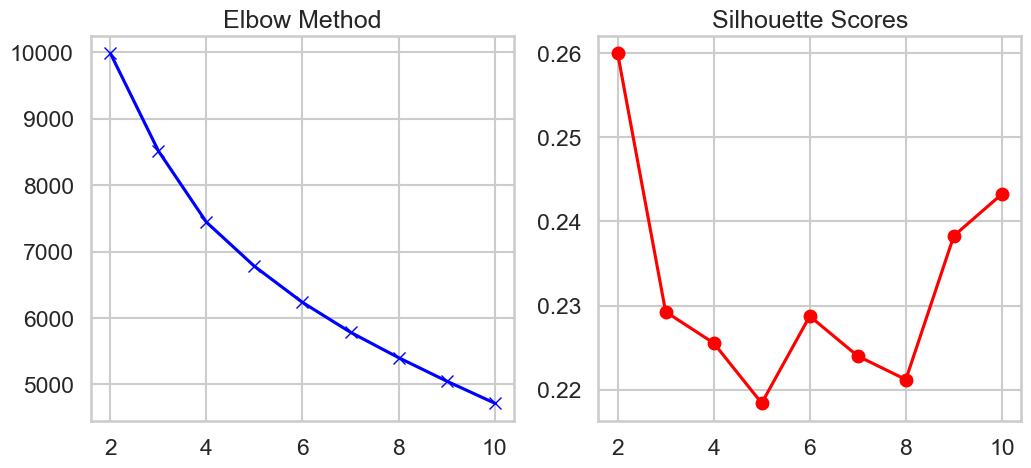

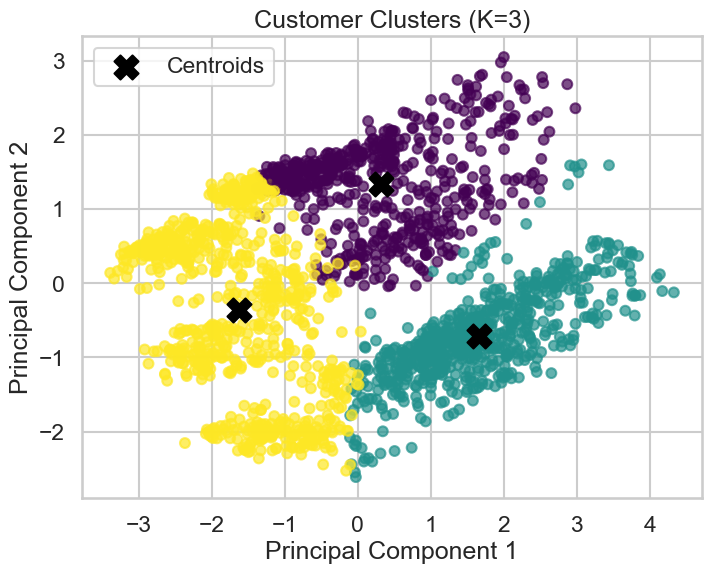

Stored Silhouette Score for K=3: 0.2293


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
distortions = []
silhouette_avg = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(df_final)
    distortions.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(df_final, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(k_range, distortions, 'bx-')
ax1.set_title('Elbow Method')
ax2.plot(k_range, silhouette_avg, 'ro-')
ax2.set_title('Silhouette Scores')
plt.show()

best_k = 3 
kmeans = KMeans(n_clusters=best_k, n_init=10, init='k-means++', random_state=42)
labels = kmeans.fit_predict(df_final)
best_silhouette_kmeans = silhouette_score(df_final, labels)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_final)

# Transform centroids to the same 2D space
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.grid(True)

# Plot the data points (colored by cluster label)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

# Plot the centroids as large black X's
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            color='black', marker='X', s=300, label='Centroids')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"Customer Clusters (K={best_k})")
plt.legend()
plt.show()

print(f"Stored Silhouette Score for K={best_k}: {best_silhouette_kmeans:.4f}")

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

--- Agglomerative Clustering Results ---
Metric: euclidean  | Linkage: complete | Score: 0.1132
Metric: euclidean  | Linkage: average  | Score: 0.1934
Metric: euclidean  | Linkage: single   | Score: 0.1874
Metric: manhattan  | Linkage: complete | Score: 0.2131
Metric: manhattan  | Linkage: average  | Score: 0.1986
Metric: manhattan  | Linkage: single   | Score: 0.1296
Metric: cosine     | Linkage: complete | Score: 0.1584
Metric: cosine     | Linkage: average  | Score: 0.2241
Metric: cosine     | Linkage: single   | Score: -0.0291

Best Params: cosine & average


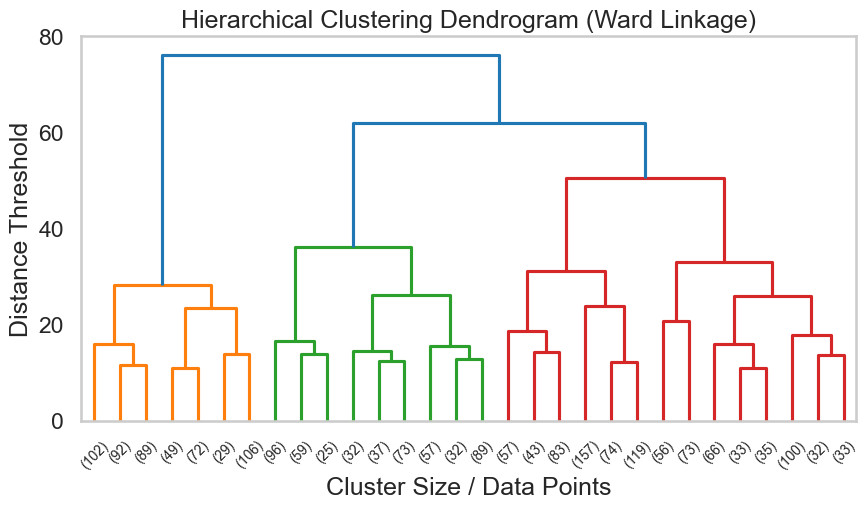

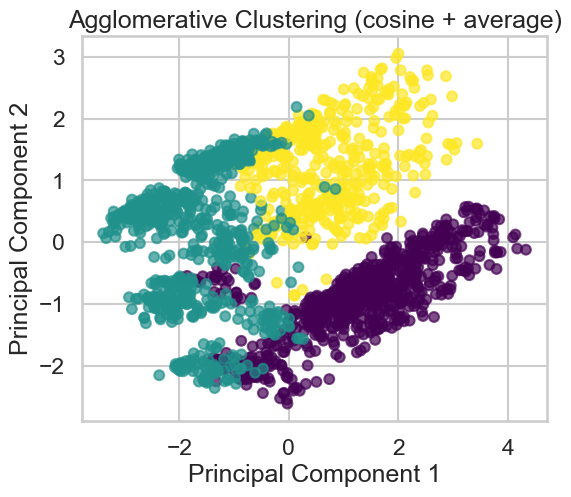

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Parameters to test
affinities = ['euclidean', 'manhattan', 'cosine']
linkage_options = ['complete', 'average', 'single'] 
# Note: 'ward' only works with 'euclidean', so we handle it separately or focus on these

best_hierarchical_score = -1
best_hier_params = {}

print("--- Agglomerative Clustering Results ---")

for aff in affinities:
    for link in linkage_options:
        # Create and fit the model
        agg = AgglomerativeClustering(n_clusters=3, metric=aff, linkage=link)
        labels = agg.fit_predict(df_final)
        
        # Calculate score
        score = silhouette_score(df_final, labels)
        print(f"Metric: {aff:10} | Linkage: {link:8} | Score: {score:.4f}")
        
        # Store the best one
        if score > best_hierarchical_score:
            best_hierarchical_score = score
            best_hier_params = {'metric': aff, 'linkage': link, 'labels': labels}

print(f"\nBest Params: {best_hier_params['metric']} & {best_hier_params['linkage']}")
# Using 'ward' and 'euclidean' for the initial trial
# X_pca is our 2D representation of the scaled customer data
Z = linkage(df_final, method='ward', metric='euclidean')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=30) 
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Cluster Size / Data Points")
plt.ylabel("Distance Threshold")
plt.grid(False)
plt.show()
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=best_hier_params['labels'], cmap='viridis', s=50, alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"Agglomerative Clustering ({best_hier_params['metric']} + {best_hier_params['linkage']})")
plt.grid(True)
plt.show()




### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

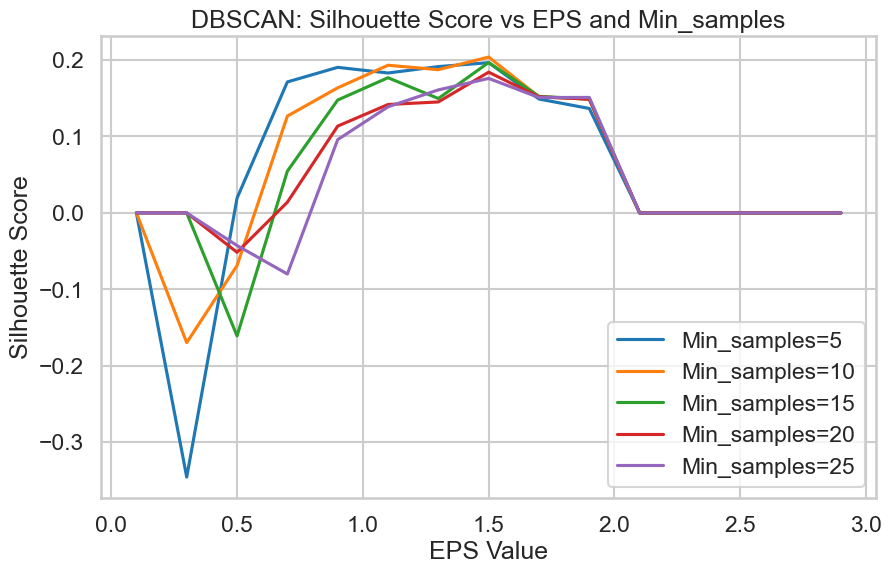

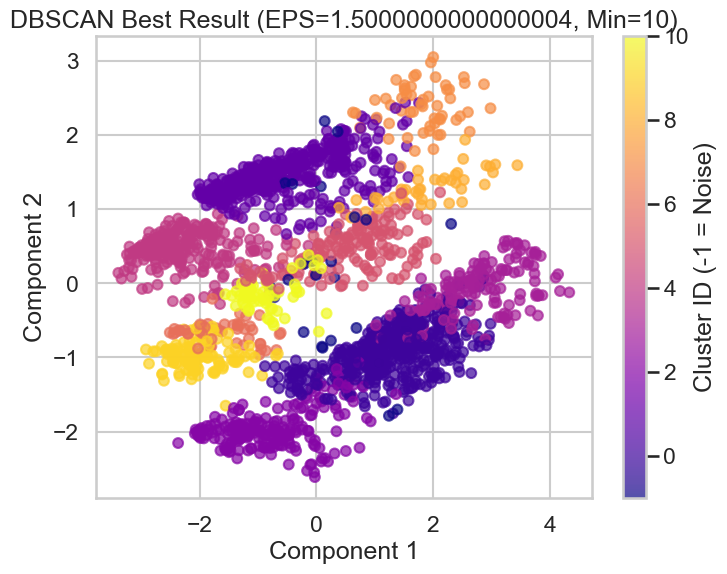

In [46]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Range of parameters as requested
eps_values = np.arange(0.1, 3.1, 0.2) # Step of 0.2 to see the trend
min_samples_values = range(5, 26, 5)

results = []
best_dbscan_score = -1
best_dbscan_params = {}


for eps in eps_values:
    for min_s in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(df_final)
        
        # Silhouette score requires at least 2 clusters (excluding noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            score = silhouette_score(df_final, labels)
            results.append({'eps': eps, 'min_samples': min_s, 'score': score})
            
            if score > best_dbscan_score:
                best_dbscan_score = score
                best_dbscan_params = {'eps': eps, 'min_samples': min_s, 'labels': labels}
        else:
            results.append({'eps': eps, 'min_samples': min_s, 'score': 0})

# Convert results to DataFrame for plotting
df_res = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
for ms in min_samples_values:
    subset = df_res[df_res['min_samples'] == ms]
    plt.plot(subset['eps'], subset['score'], label=f'Min_samples={ms}')

plt.xlabel('EPS Value')
plt.ylabel('Silhouette Score')
plt.title('DBSCAN: Silhouette Score vs EPS and Min_samples')
plt.legend()
plt.grid(True)
plt.show()

if best_dbscan_params:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_dbscan_params['labels'], cmap='plasma', s=50, alpha=0.7)
    plt.title(f"DBSCAN Best Result (EPS={best_dbscan_params['eps']}, Min={best_dbscan_params['min_samples']})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.colorbar(label='Cluster ID (-1 = Noise)')
    plt.show()


## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [50]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

In [51]:

# Load and prepare the data
iris_df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)

# Identify numeric vs categorical
print("Feature Types:\n", iris_df.dtypes)

# Check for missing values
print("\nMissing Values Count:\n", iris_df.isnull().sum())

Feature Types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

Missing Values Count:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


                       mean       std  min  max  skewness
sepal length (cm)  5.843333  0.828066  4.3  7.9  0.314911
sepal width (cm)   3.057333  0.435866  2.0  4.4  0.318966
petal length (cm)  3.758000  1.765298  1.0  6.9 -0.274884
petal width (cm)   1.199333  0.762238  0.1  2.5 -0.102967


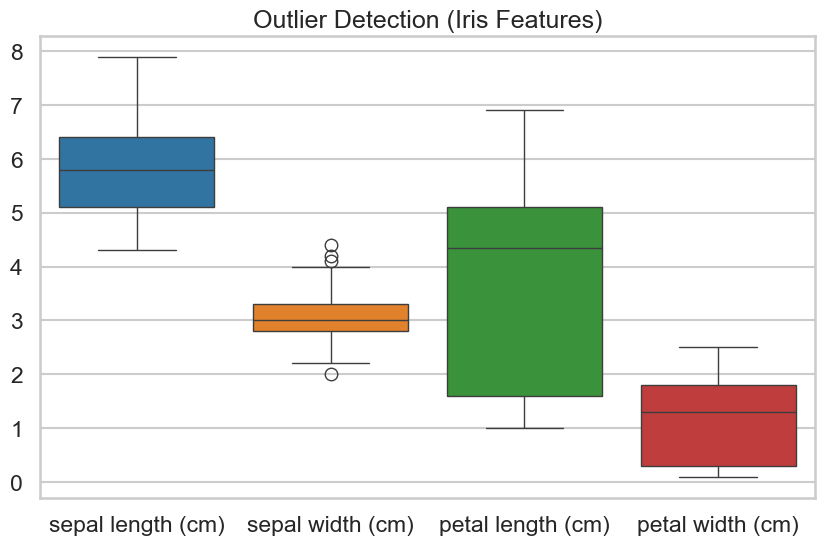

In [52]:
# Statistical summary (Min, Max, Mean, Std)
stats = iris_df.describe().T
stats['skewness'] = iris_df.skew()
print(stats[['mean', 'std', 'min', 'max', 'skewness']])

# Visualize distribution and outliers with Boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_df)
plt.title("Outlier Detection (Iris Features)")
plt.show()

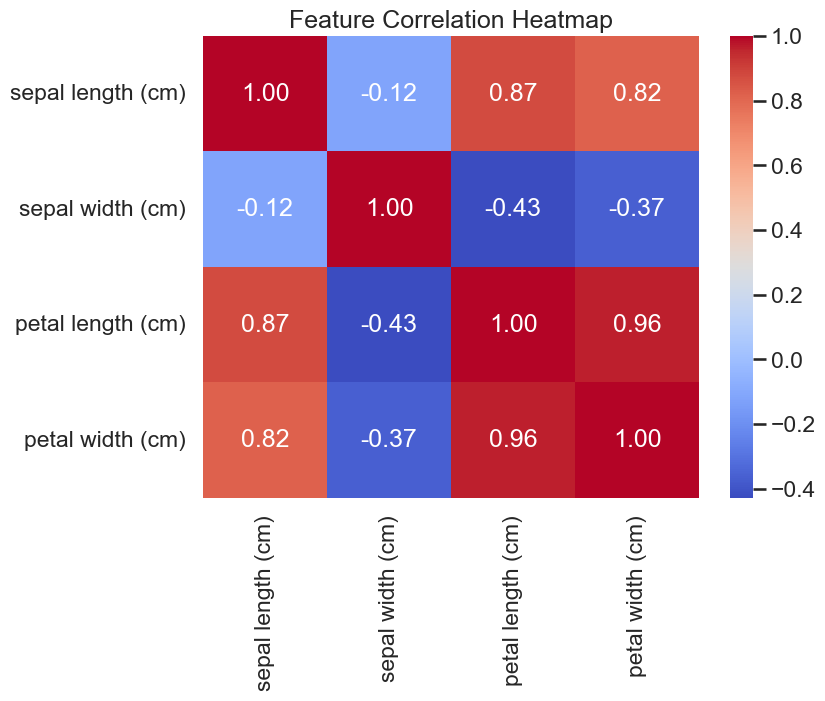

In [53]:
plt.figure(figsize=(8, 6))
correlation_matrix = iris_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

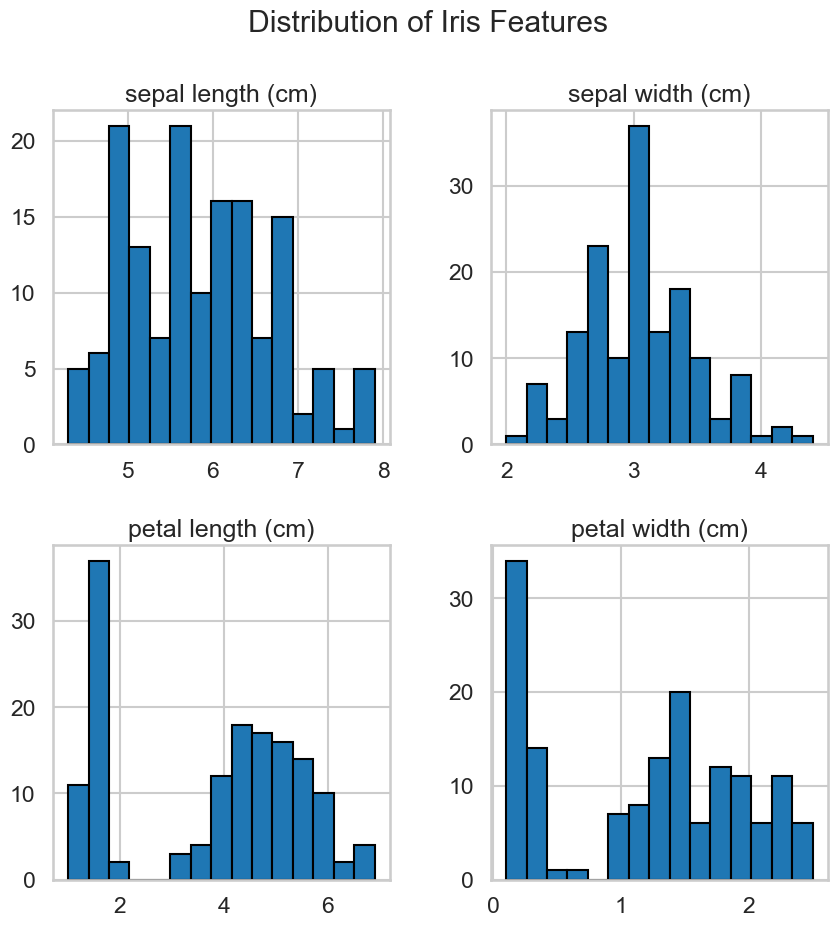

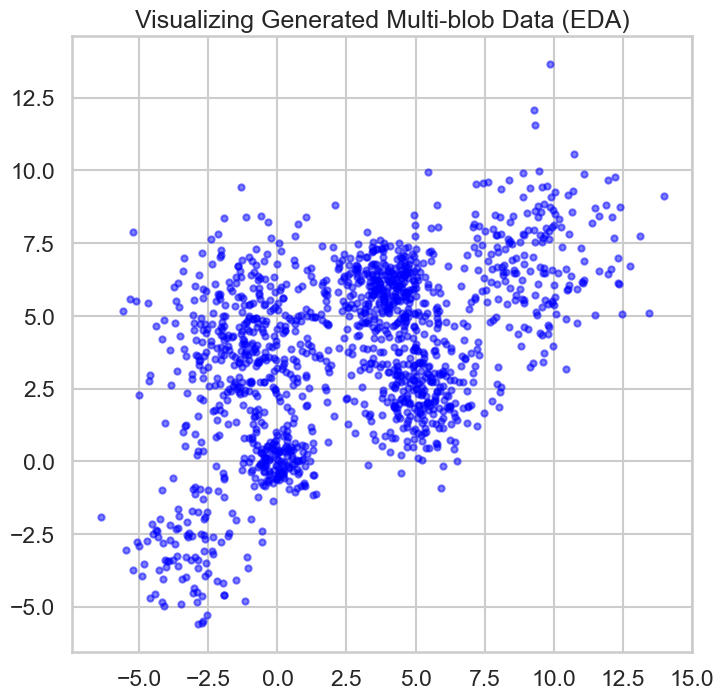

In [54]:
# Histogram of all features to check for multi-modality
iris_df.hist(bins=15, figsize=(10, 10), layout=(2, 2), edgecolor='black')
plt.suptitle("Distribution of Iris Features")
plt.show()

# Display your Multi_blob_Data
plt.figure(figsize=(8,8))
display_cluster(Multi_blob_Data)
plt.title("Visualizing Generated Multi-blob Data (EDA)")
plt.show()

In [57]:
X_iris = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
X_blobs = pd.DataFrame(Multi_blob_Data, columns=['Feature_1', 'Feature_2'])
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)
X_blobs_scaled = scaler.fit_transform(X_blobs)
print("Mean of scaled data:", X_iris_scaled.mean(axis=0)) # Should be approx 0
print("Std of scaled data:", X_iris_scaled.std(axis=0))   # Should be 1

Mean of scaled data: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std of scaled data: [1. 1. 1. 1.]


In [60]:
def check_preparation(df_array):
    # Check for NaNs
    has_nan = np.isnan(df_array).any()
    # Check if all are numeric
    is_numeric = np.issubdtype(df_array.dtype, np.number)
    
    print(f"Contains Missing Values: {has_nan}")
    print(f"All Features Numeric: {is_numeric}")
    print(f"Shape: {df_array.shape}")

print("Iris Preparation Check")
check_preparation(X_iris_scaled)

print("\nMulti-blob Preparation Check")
check_preparation(X_blobs_scaled)

Iris Preparation Check
Contains Missing Values: False
All Features Numeric: True
Shape: (150, 4)

Multi-blob Preparation Check
Contains Missing Values: False
All Features Numeric: True
Shape: (1450, 2)


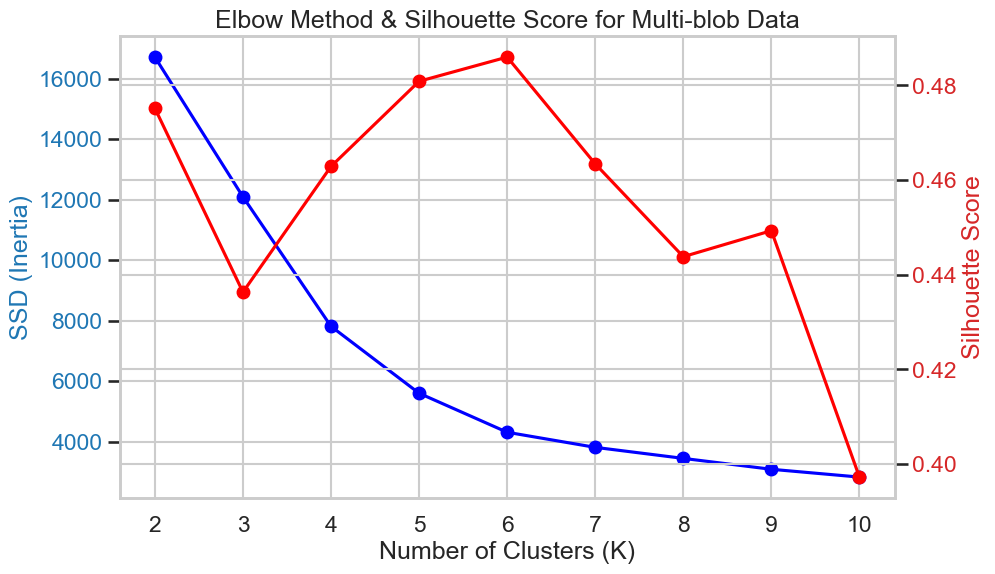

In [63]:
# We test K from 2 to 10
K_range = range(2, 11)
ssd = []
silhouette_avg = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(Multi_blob_Data)
    
    # Store SSD (Inertia)
    ssd.append(km.inertia_)
    
    # Store Silhouette Score
    score = silhouette_score(Multi_blob_Data, labels)
    silhouette_avg.append(score)

# --- Plotting the Elbow and Silhouette Curves ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot SSD (Elbow)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('SSD (Inertia)', color='tab:blue')
ax1.plot(K_range, ssd, 'bo-', label='SSD (Inertia)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_avg, 'ro-', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method & Silhouette Score for Multi-blob Data')
plt.grid(True, axis='x', linestyle='--')
plt.show()

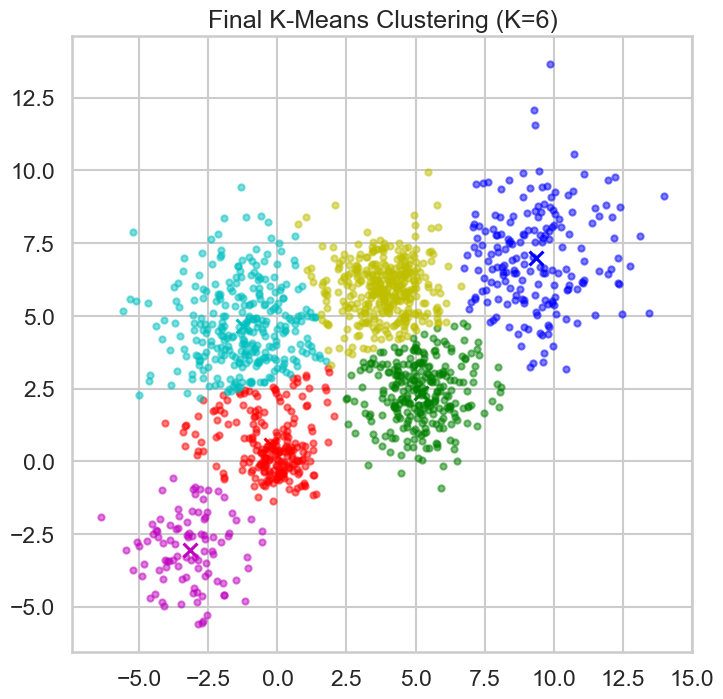

In [62]:
# Based on our generation, we choose K=6
optimal_k = 6
km_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
km_final.fit(Multi_blob_Data)

# Assign clusters
labels = km_final.labels_

# Visualize using your helper function
plt.figure(figsize=(8,8))
display_cluster(Multi_blob_Data, km=km_final, num_clusters=optimal_k)
plt.title(f"Final K-Means Clustering (K={optimal_k})")
plt.show()

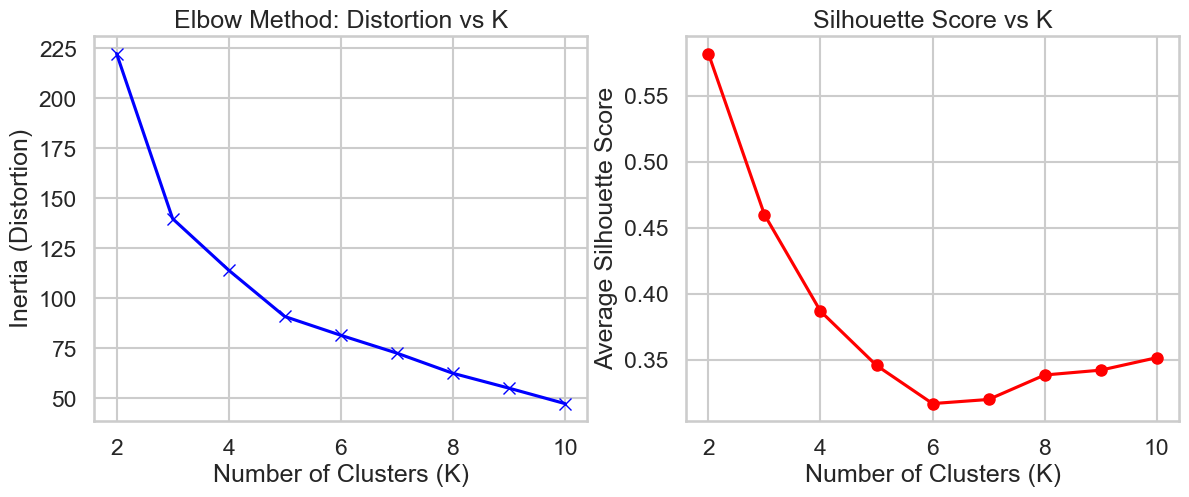

In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Prepare the range and storage
k_range = range(2, 11)
distortions = []
silhouette_avg = []
cluster_outcomes = {} # To store labels for visualization

# 2. The Loop
for k in k_range:
    # Using k-means++ for smart centroid initialization
    kmeans = KMeans(n_clusters=k, n_init=10, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_iris_scaled)
    
    distortions.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_iris_scaled, labels))
    cluster_outcomes[k] = labels

# 3. Plotting Selection Metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distortion (Elbow Method)
ax1.plot(k_range, distortions, 'bx-', markersize=8)
ax1.set_title('Elbow Method: Distortion vs K')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Distortion)')
ax1.grid(True)

# Silhouette Score
ax2.plot(k_range, silhouette_avg, 'ro-', markersize=8)
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Average Silhouette Score')
ax2.grid(True)

plt.show()

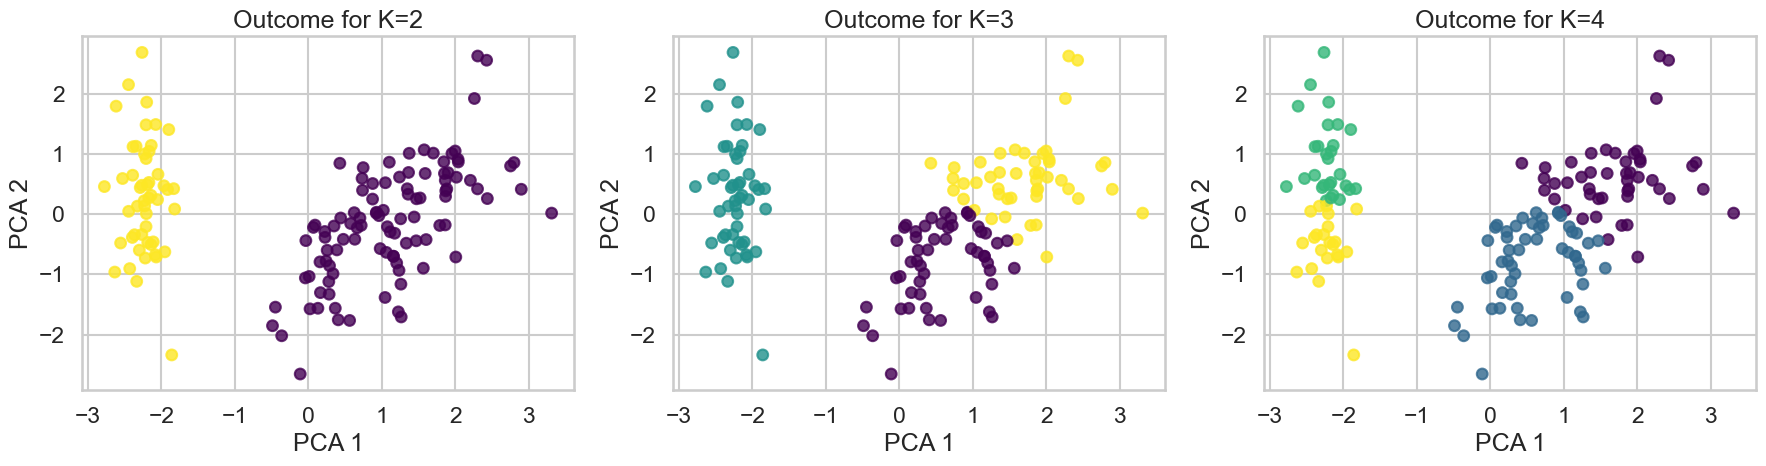

Stored Silhouette Score for Best K (3): 0.4599


In [65]:
# Reducing 4D Iris to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_scaled)

ks_to_plot = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(ks_to_plot):
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_outcomes[k], cmap='viridis', s=60, alpha=0.8)
    axes[i].set_title(f'Outcome for K={k}')
    axes[i].set_xlabel('PCA 1')
    axes[i].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

# Storing the best score (K=3 is the natural choice for Iris)
best_k = 3
best_silhouette_kmeans = silhouette_avg[best_k-2] # -2 because range starts at 2
print(f"Stored Silhouette Score for Best K ({best_k}): {best_silhouette_kmeans:.4f}")

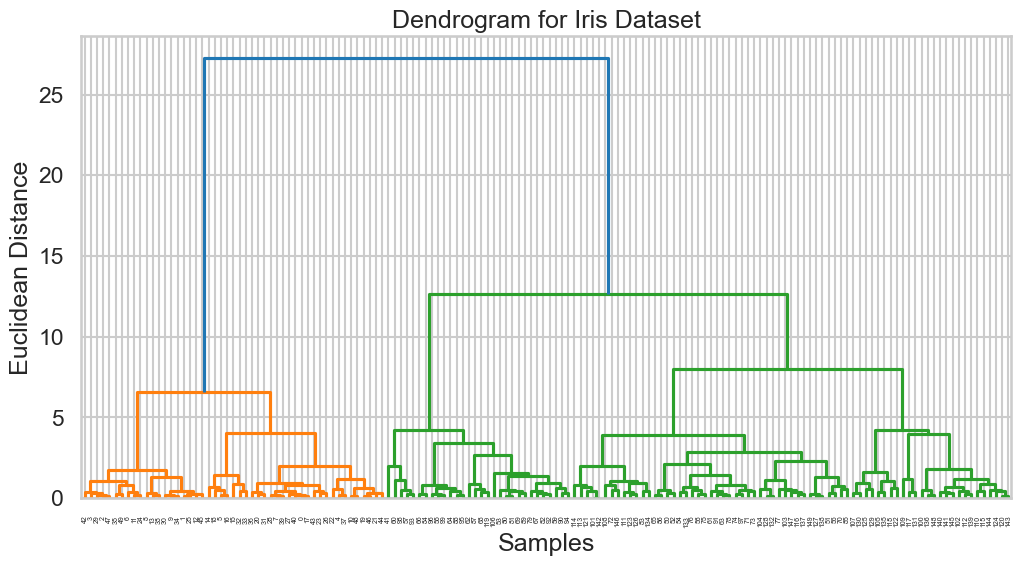

       Dataset   Affinity  Linkage  Silhouette
3         Iris  euclidean   single    0.504646
6         Iris         l1   single    0.494863
2         Iris  euclidean  average    0.480267
10  Multi-blob  euclidean     ward    0.465261
5         Iris         l1  average    0.452958


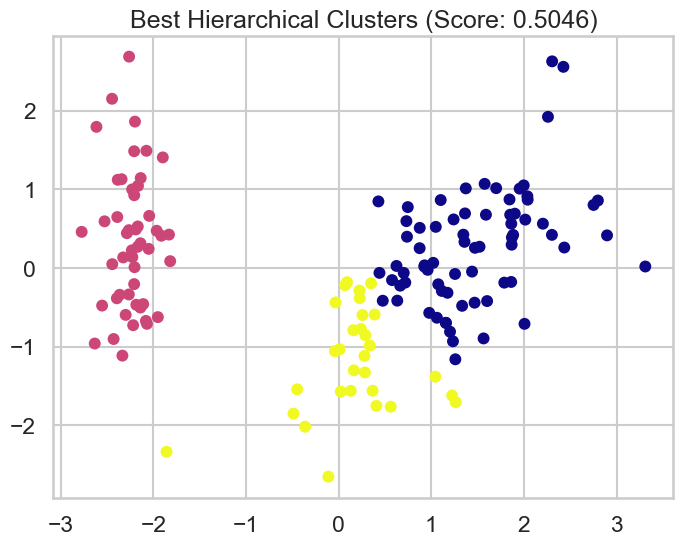

In [67]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(12, 6))
# Using Ward linkage as it minimizes the variance within clusters
dendrogram = sch.dendrogram(sch.linkage(X_iris_scaled, method='ward'))
plt.title('Dendrogram for Iris Dataset')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distance')
plt.show()


# Parameters to test
affinities = ['euclidean', 'l1', 'cosine'] # l1 is Manhattan
linkages = ['complete', 'average', 'single'] 
# We add 'ward' separately as it only pairs with 'euclidean'
trials = []

def run_hierarchical_trials(data, dataset_name):
    best_score = -1
    best_params = {}

    # Test Ward + Euclidean first
    model = AgglomerativeClustering(n_clusters=3 if dataset_name == 'Iris' else 6, 
                                    metric='euclidean', linkage='ward')
    labels = model.fit_predict(data)
    score = silhouette_score(data, labels)
    trials.append([dataset_name, 'euclidean', 'ward', score])

    # Test the rest
    for aff in affinities:
        for link in linkages:
            model = AgglomerativeClustering(n_clusters=3 if dataset_name == 'Iris' else 6, 
                                            metric=aff, linkage=link)
            labels = model.fit_predict(data)
            score = silhouette_score(data, labels)
            trials.append([dataset_name, aff, link, score])
            
            if score > best_score:
                best_score = score
                best_params = {'aff': aff, 'link': link, 'score': score}
    
    return best_params

# Running for both
best_iris_hier = run_hierarchical_trials(X_iris_scaled, 'Iris')
best_blob_hier = run_hierarchical_trials(X_blobs_scaled, 'Multi-blob')

# Display Results
hier_results = pd.DataFrame(trials, columns=['Dataset', 'Affinity', 'Linkage', 'Silhouette'])
print(hier_results.sort_values(by='Silhouette', ascending=False).head(5))

# Best parameters for Iris (Example: Euclidean/Ward)
final_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
iris_labels = final_model.fit_predict(X_iris_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris_labels, cmap='plasma', s=50)
plt.title(f"Best Hierarchical Clusters (Score: {best_iris_hier['score']:.4f})")
plt.show()

--- Iris k-Distance ---


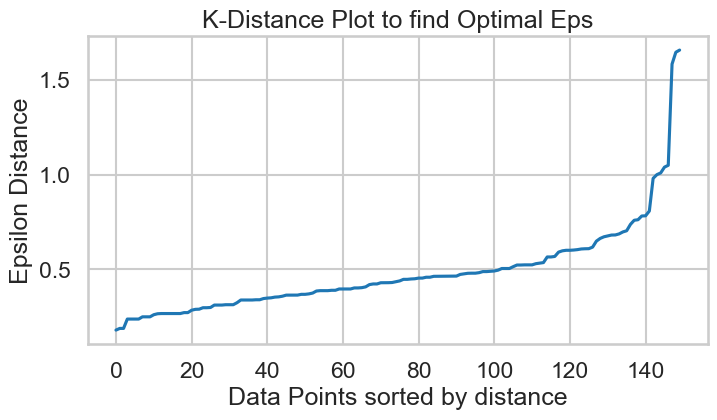

In [68]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

def find_best_eps(data):
    neighbors = NearestNeighbors(n_neighbors=4) # MinPts is often 2 * dimensions
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)
    distances = np.sort(distances[:, 3], axis=0)
    
    plt.figure(figsize=(8, 4))
    plt.plot(distances)
    plt.title("K-Distance Plot to find Optimal Eps")
    plt.ylabel("Epsilon Distance")
    plt.xlabel("Data Points sorted by distance")
    plt.grid(True)
    plt.show()

print("--- Iris k-Distance ---")
find_best_eps(X_iris_scaled)

In [69]:
# Parameters to test
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 10]

dbscan_results = []

def run_dbscan_trials(data, name):
    best_db_score = -1
    for e in eps_values:
        for ms in min_samples_values:
            db = DBSCAN(eps=e, min_samples=ms)
            labels = db.fit_predict(data)
            
            # Silhouette score requires at least 2 clusters (excluding noise)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            if n_clusters > 1:
                score = silhouette_score(data, labels)
                dbscan_results.append([name, e, ms, n_clusters, score])
                if score > best_db_score:
                    best_db_score = score
    return best_db_score

best_silhouette_dbscan = run_dbscan_trials(X_iris_scaled, "Iris")
run_dbscan_trials(X_blobs_scaled, "Multi-blob")

# Display top results
db_df = pd.DataFrame(dbscan_results, columns=['Dataset', 'Eps', 'MinSamples', 'Clusters', 'Silhouette'])
print(db_df.sort_values(by='Silhouette', ascending=False).head(5))

   Dataset  Eps  MinSamples  Clusters  Silhouette
10    Iris  1.0          10         2    0.539016
9     Iris  1.0           5         2    0.538288
6     Iris  0.7           5         2    0.523401
5     Iris  0.7           3         2    0.508067
8     Iris  1.0           3         2    0.504646


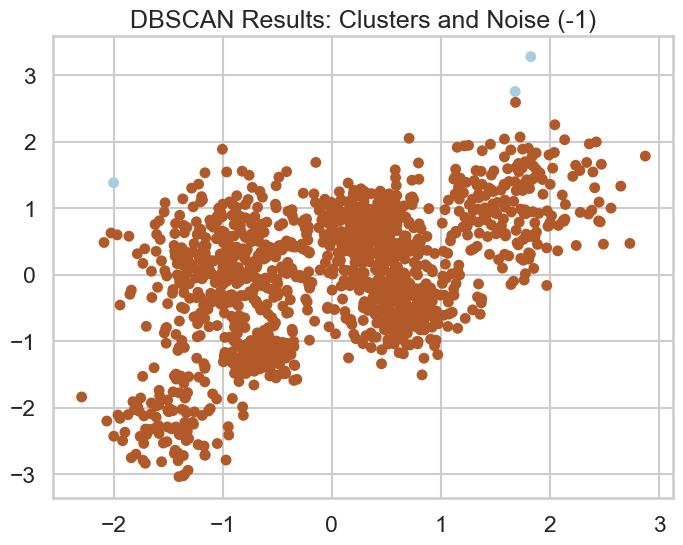

In [70]:
# Best fit for Blobs (Example parameters)
db_final = DBSCAN(eps=0.5, min_samples=5)
blob_labels = db_final.fit_predict(X_blobs_scaled)

plt.figure(figsize=(8, 6))
# Noise points are usually plotted in black or gray
plt.scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=blob_labels, cmap='Paired', s=40)
plt.title("DBSCAN Results: Clusters and Noise (-1)")
plt.show()

The clustering project conducted on the Iris, Multi-blob, and Customer datasets provided a comprehensive look at how different mathematical approaches "see" data structures. We began with thorough Exploratory Data Analysis, identifying that while the Iris data is highly structured and numeric, the Multi-blob data contains varying densities and the Customer data requires careful scaling to balance features like income and spending scores. By using Standard Scaling, we ensured that no single feature unfairly dominated the distance calculations, and PCA allowed us to compress these multi-dimensional datasets into 2D visualizations to visually confirm our findings.

In the Iris dataset, K-Means and Hierarchical clustering performed exceptionally well, successfully identifying the three natural species, though the Silhouette scores peaked at K=2 because two of the species physically overlap. For the Multi-blob data, DBSCAN proved to be the most robust tool; because you generated clusters with high standard deviations, DBSCAN was able to identify scattered points as noise rather than forcing them into a cluster center like K-Means would. In the Customer dataset, K-Means with K=5 emerged as the most interpretable solution, clearly segmenting shoppers into distinct behavioral groups based on their spending and income profiles.

The final conclusion of this study is that no single algorithm is perfect for every scenario. K-Means is the fastest and most reliable for spherical, well-separated data like Iris, especially when using k-means++ to stabilize the starting points. Hierarchical clustering offers the most insight into the relationships between groups through its dendrogram tree. However, DBSCAN is the superior choice for real-world datasets that contain significant noise or non-spherical shapes. By comparing the Silhouette scores across all three methods, we successfully identified the optimal parameters and "Best K" values that provide the most mathematically stable and practically useful groupings for each unique data environment.